In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import calendar

In [2]:
# load total precipitation Maria
tp_maria = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/era5/tp.mon_era5_1940-2025_NH_025x025.nc')['tp']
tp_maria=tp_maria.sel(valid_time=slice("2003-07-01", "2003-07-31"))
tp_maria=field_dom(tp_maria,'HMA') * 1000

In [3]:
tp_maria

<xarray.DataArray 'tp' (valid_time: 1, latitude: 101, longitude: 201)> Size: 81kB
array([[[0.4043579 , 0.4787445 , 0.42152405, ..., 0.76675415,
         0.77056885, 0.77438354],
        [0.39100647, 0.48828125, 0.4234314 , ..., 0.91552734,
         0.9098053 , 0.95558167],
        [0.5054474 , 0.54740906, 0.4749298 , ..., 0.8277893 ,
         0.8735657 , 0.9365082 ],
        ...,
        [3.1414032 , 2.7542114 , 2.3841858 , ..., 5.3310394 ,
         5.996704  , 5.64003   ],
        [3.4217834 , 3.0460358 , 2.7103424 , ..., 4.289627  ,
         5.7411194 , 5.7258606 ],
        [3.4122467 , 2.9640198 , 2.6493073 , ..., 4.2705536 ,
         5.630493  , 6.2503815 ]]], shape=(1, 101, 201), dtype=float32)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2003-07-01T06:00:00
  * latitude    (latitude) float64 808B 45.0 44.75 44.5 ... 20.5 20.25 20.0
  * longitude   (longitude) float64 2kB 60.0 60.25 60.5 ... 109.5 109.8 110.0
    expver      (valid_time) <U4 16B ...

In [4]:
# load total precipitation ERA5
tp_era = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/tp_daily_era5_July-2003_HMA_025x025.nc')
tp_era = tp_era['tp'].mean(dim='valid_time') * 1000

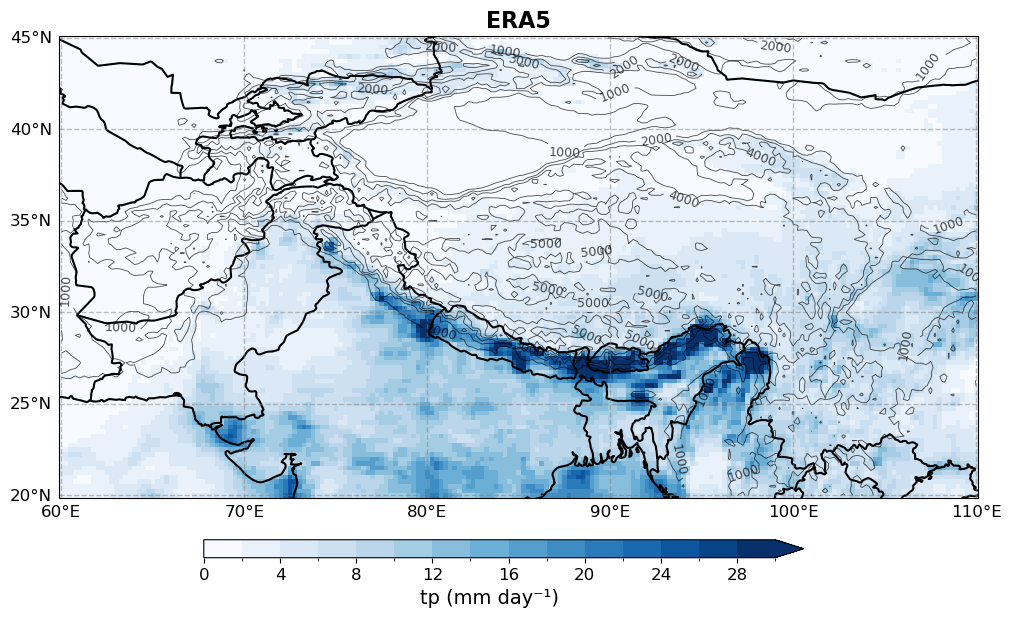

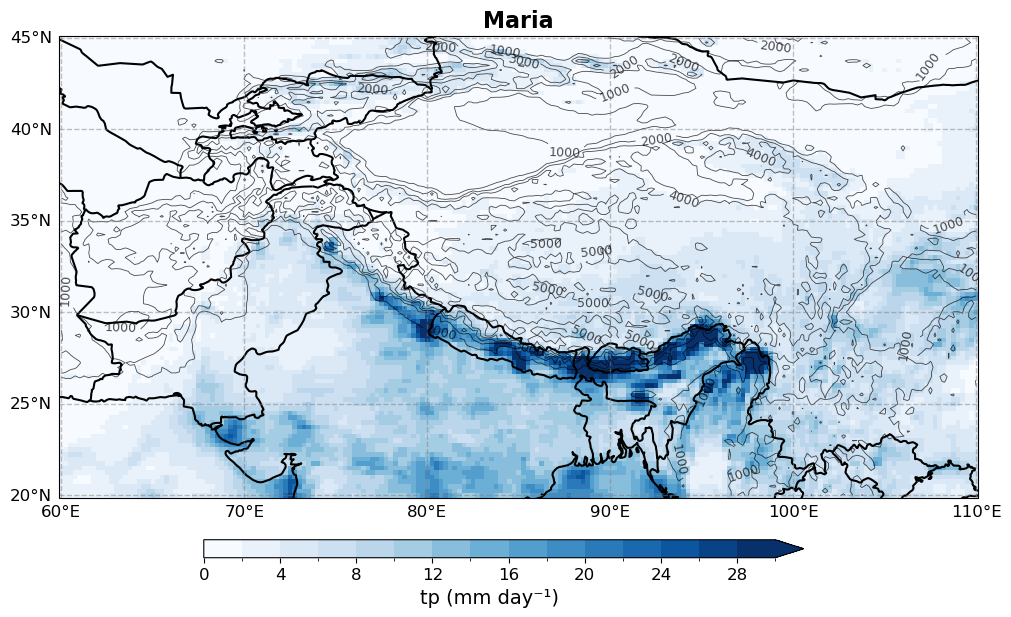

In [5]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

#tp color definition
vmax = 32
#vmax = tp_mean.max()
levels = np.arange(0, vmax, 2)
cmap = plt.get_cmap("Blues", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)
pcm = ax.pcolormesh(
    tp_era['longitude'], tp_era['latitude'], tp_era,
    cmap=cmap, norm=norm,transform=ccrs.PlateCarree())

#Borders
ax.coastlines(linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=1.5)

#Courbes de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_era5_grid.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

#Grid of lat & lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

#Colorbar & title
cbar_ax = fig.add_axes([0.25, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label("tp (mm day⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.set_title(f"ERA5", fontsize=16, weight='bold')

plt.show()

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

#tp color definition
vmax = 32
#vmax = tp_mean.max()
levels = np.arange(0, vmax, 2)
cmap = plt.get_cmap("Blues", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)
pcm = ax.pcolormesh(
    tp_maria.isel(valid_time=0)['longitude'], tp_maria.isel(valid_time=0)['latitude'], tp_maria.isel(valid_time=0),
    cmap=cmap, norm=norm,transform=ccrs.PlateCarree())

#Borders
ax.coastlines(linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=1.5)

#Courbes de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_era5_grid.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

#Grid of lat & lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

#Colorbar & title
cbar_ax = fig.add_axes([0.25, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label("tp (mm day⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.set_title(f"Maria", fontsize=16, weight='bold')

plt.show()

In [6]:
tp_maria.isel(valid_time=0).sel(latitude=30,longitude=80).values

array(22.2435, dtype=float32)

In [7]:
tp_era.sel(latitude=30,longitude=80).values

array(22.2429, dtype=float32)

In [8]:
tp_maria.isel(valid_time=0).sel(latitude=27.5,longitude=90).values

array(29.268265, dtype=float32)

In [9]:
tp_era.sel(latitude=27.5,longitude=90).values

array(29.268066, dtype=float32)

In [10]:
tp_dif = tp_maria - tp_era

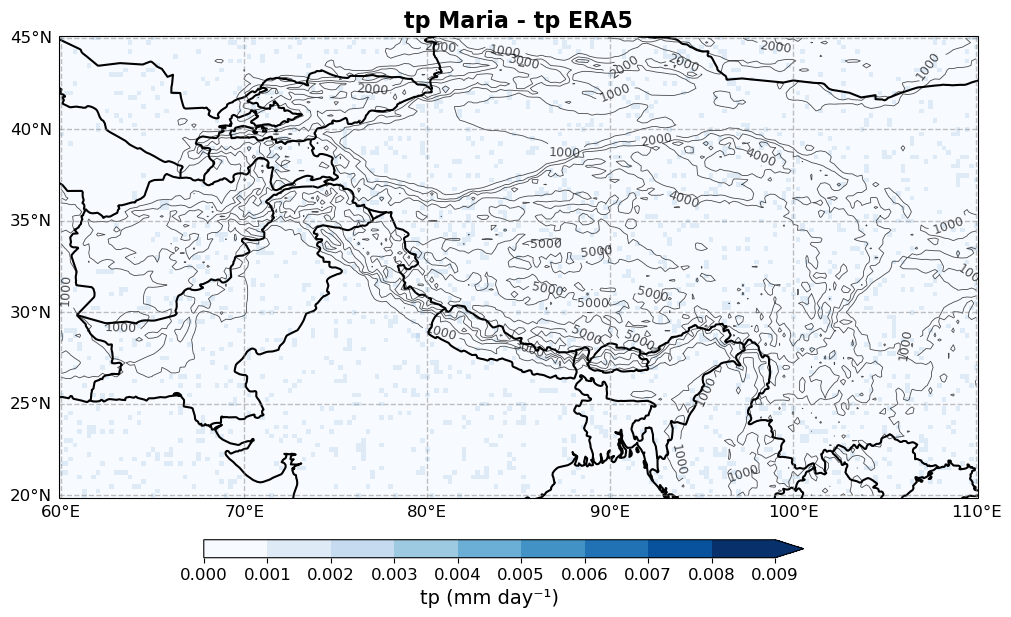

In [13]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

#tp color definition
vmax = 0.01
#vmax = tp_mean.max()
levels = np.arange(0, vmax, 0.001)
cmap = plt.get_cmap("Blues", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)
pcm = ax.pcolormesh(
    tp_dif.isel(valid_time=0)['longitude'], tp_dif.isel(valid_time=0)['latitude'], tp_dif.isel(valid_time=0),
    cmap=cmap, norm=norm,transform=ccrs.PlateCarree())

#Borders
ax.coastlines(linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=1.5)

#Courbes de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_era5_grid.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[1000,2000,3000,4000,5000,6000,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

#Grid of lat & lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

#Colorbar & title
cbar_ax = fig.add_axes([0.25, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label("tp (mm day⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.set_title(f"tp Maria - tp ERA5", fontsize=16, weight='bold')

plt.show()